# Regression Models — California Housing Dataset

> **Dataset:** California Housing Prices (Kaggle)  
> **Target:** `median_house_value` — predict house prices in California districts  
> **Models Covered:** Linear · Ridge · Lasso · Elastic Net · Polynomial Regression

---

## Table of Contents
1. [Load & Explore Data](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [Feature Engineering & Preprocessing](#3)
4. [Linear Regression](#4)
5. [Ridge Regression (L2)](#5)
6. [Lasso Regression (L1)](#6)
7. [Elastic Net](#7)
8. [Polynomial Regression](#8)
9. [Model Comparison](#9)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print('Libraries loaded successfully')

Libraries loaded successfully


---
<a id='1'></a>
## 1. Load & Explore Data

In [ ]:
df = pd.read_csv('data/housing.csv')

print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
df.head()

Shape: (20640, 10)

Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df.describe().round(2)

=== Data Types ===
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

=== Missing Values ===
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

=== Basic Statistics ===


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


In [4]:
print('ocean_proximity categories:')
print(df['ocean_proximity'].value_counts())

ocean_proximity categories:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


---
<a id='2'></a>
## 2. Exploratory Data Analysis (EDA)

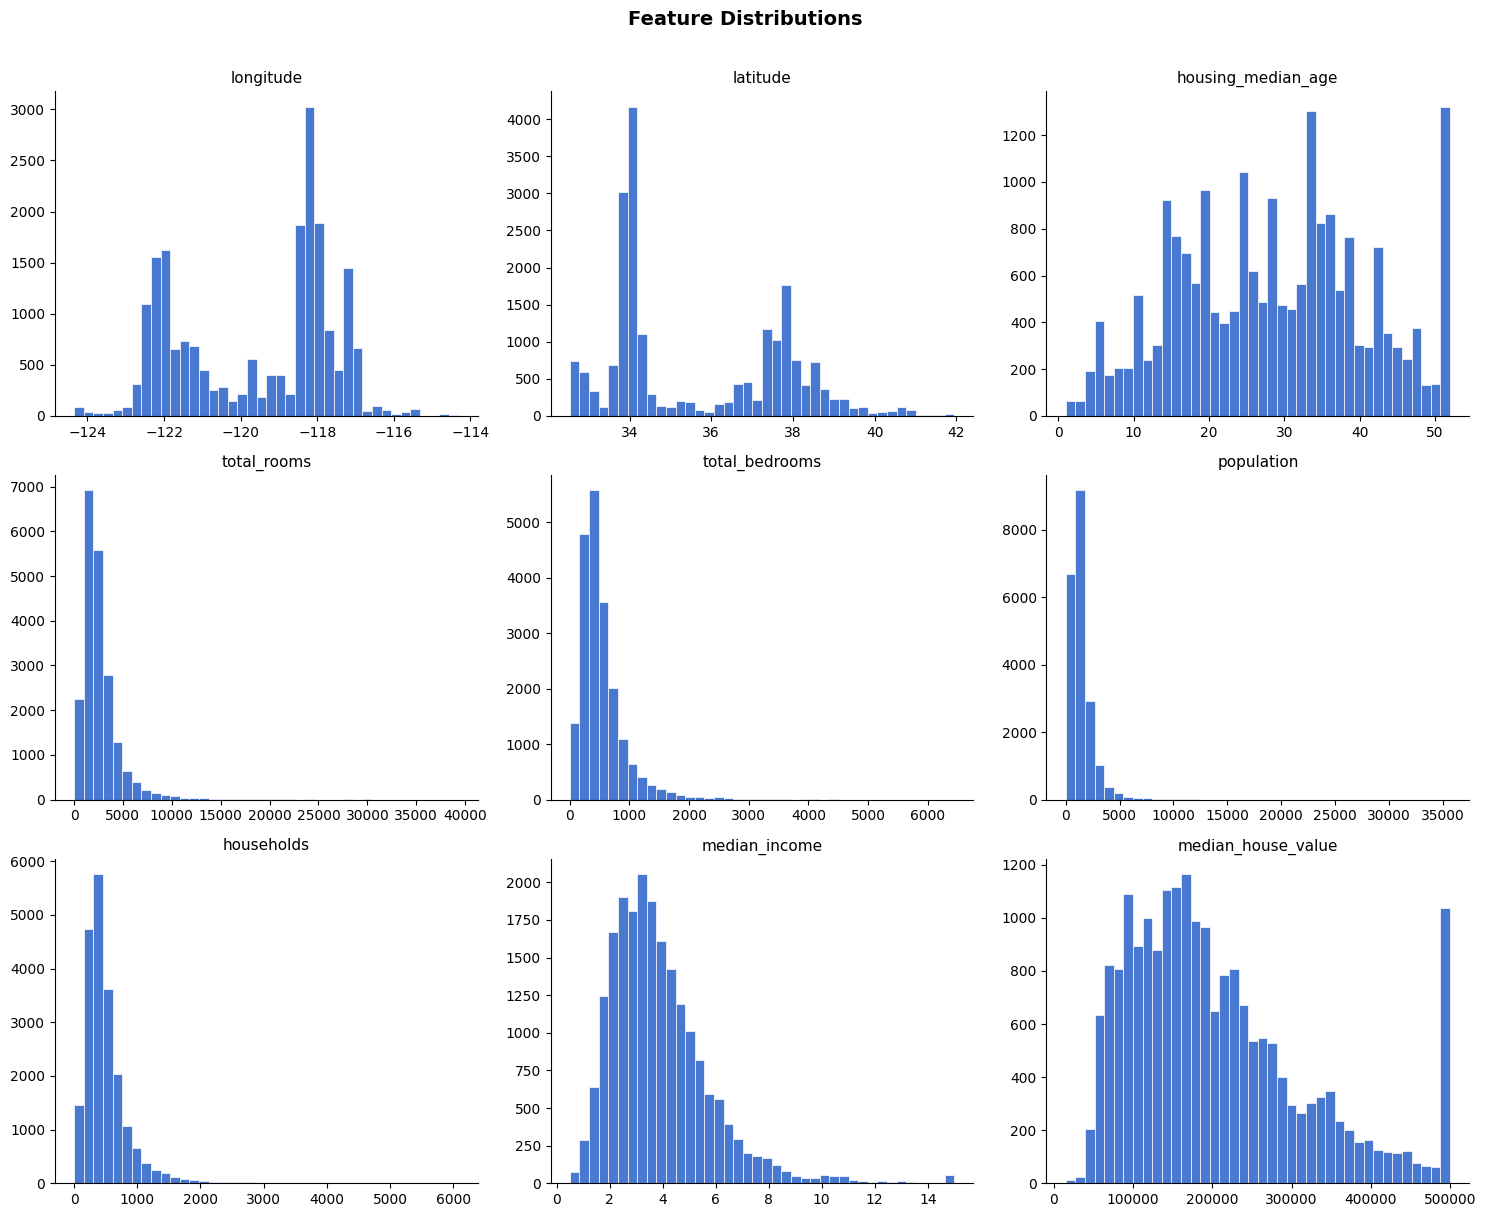

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

num_cols = df.select_dtypes(include=np.number).columns

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

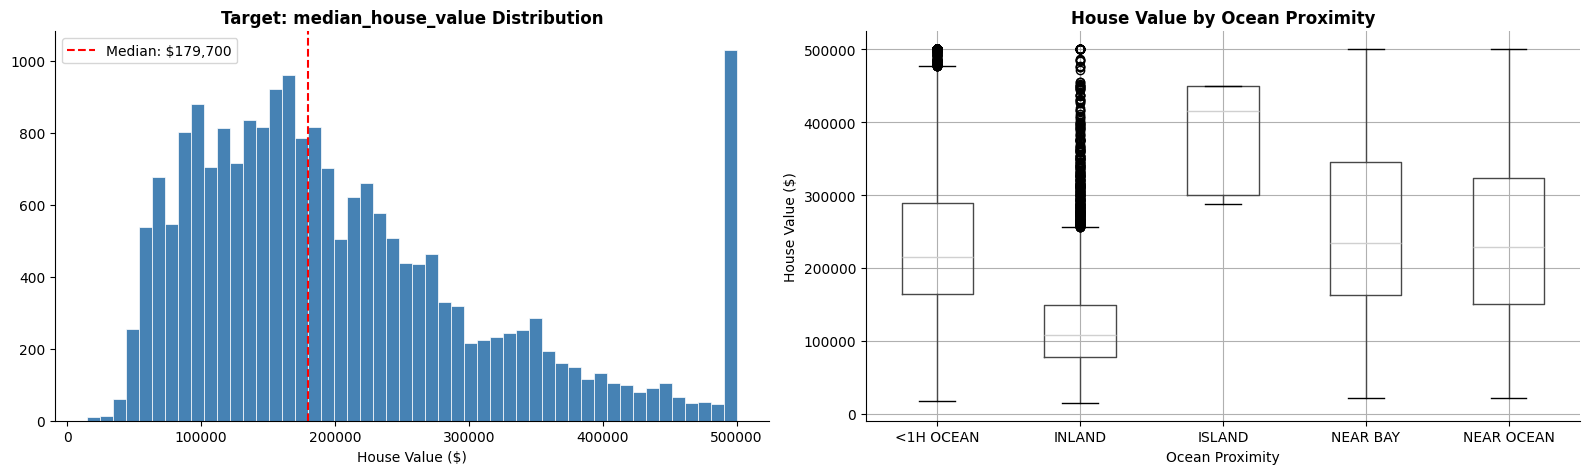

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Target distribution
axes[0].hist(df['median_house_value'], bins=50, edgecolor='white', linewidth=0.5, color='steelblue')
axes[0].axvline(df['median_house_value'].median(), color='red', linestyle='--', label=f'Median: ${df["median_house_value"].median():,.0f}')
axes[0].set_title('Target: median_house_value Distribution', fontweight='bold')
axes[0].set_xlabel('House Value ($)')
axes[0].legend()

# House value by ocean proximity
df.boxplot(column='median_house_value', by='ocean_proximity', ax=axes[1])
axes[1].set_title('House Value by Ocean Proximity', fontweight='bold')
axes[1].set_xlabel('Ocean Proximity')
axes[1].set_ylabel('House Value ($)')
plt.suptitle('')

plt.tight_layout()
plt.show()

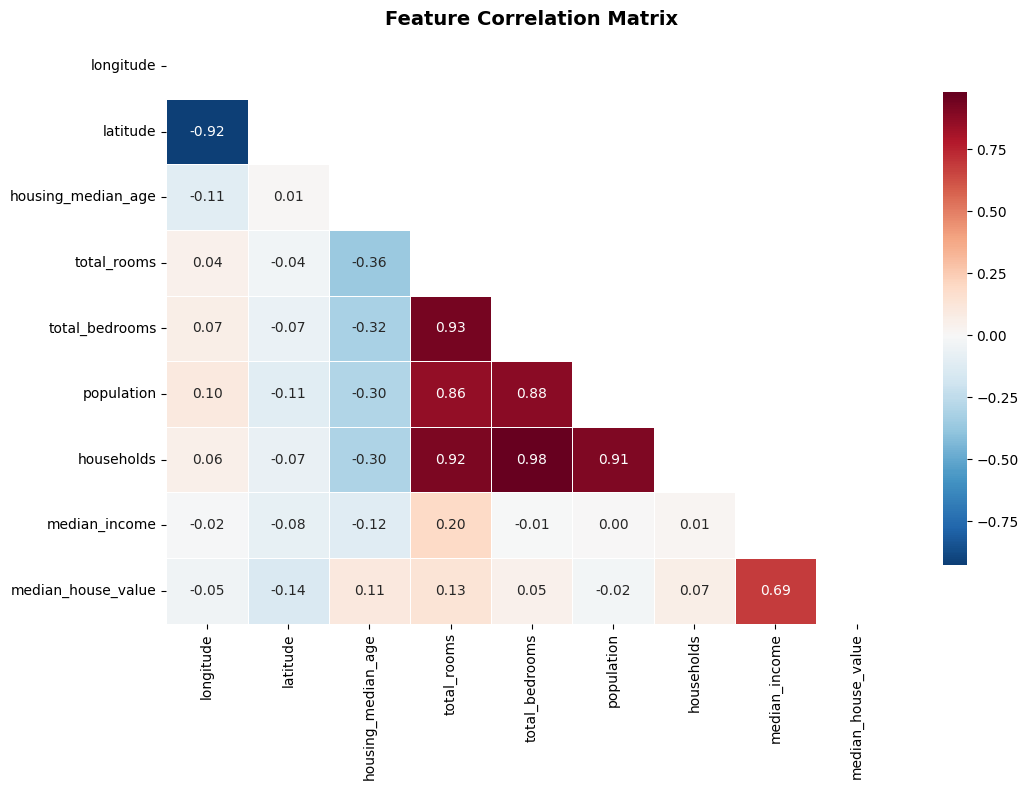

In [7]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

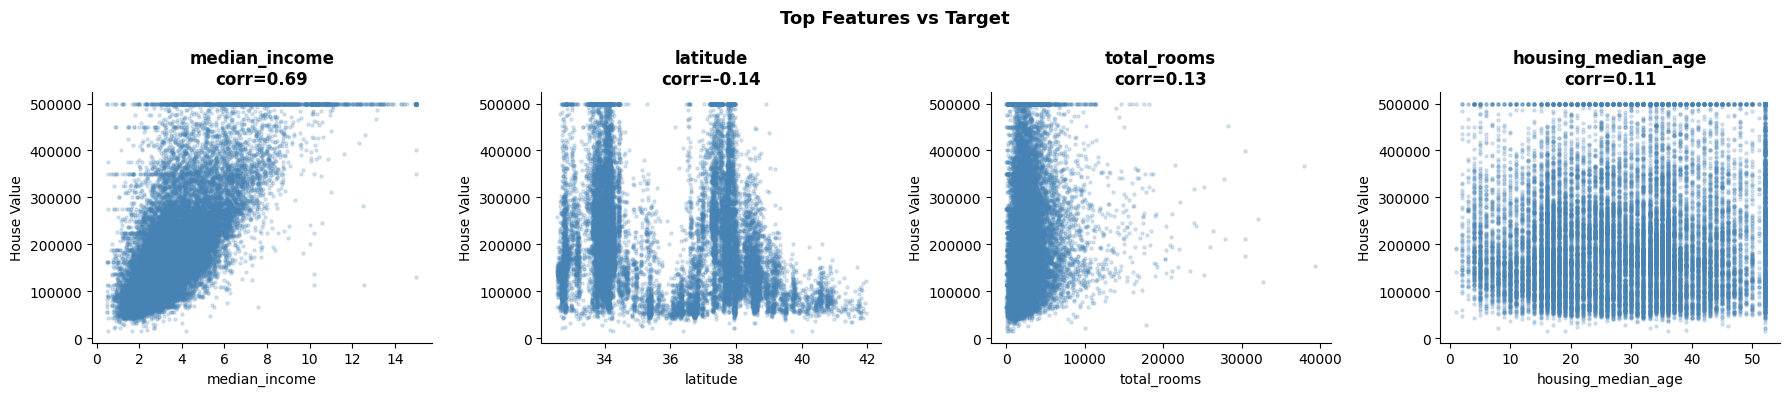

In [8]:
# Scatter plots: top correlated features vs target
top_features = corr['median_house_value'].drop('median_house_value').abs().sort_values(ascending=False).head(4).index

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['median_house_value'], alpha=0.2, s=5, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('House Value')
    axes[i].set_title(f'{feat}\ncorr={corr["median_house_value"][feat]:.2f}', fontweight='bold')

plt.suptitle('Top Features vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

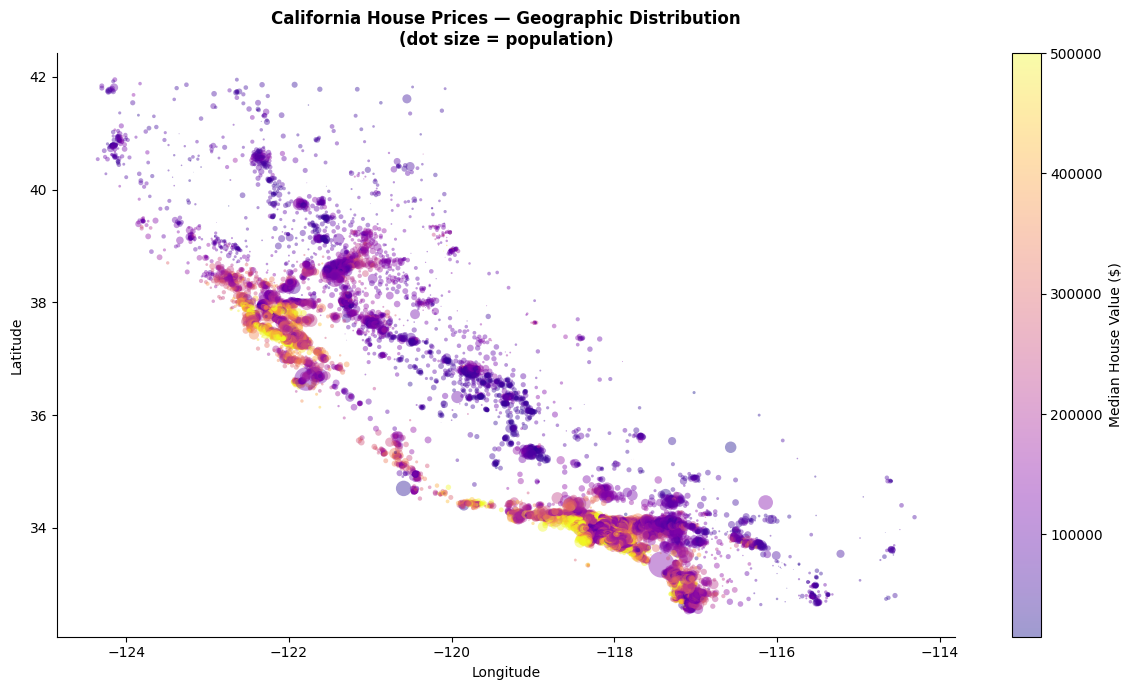

In [9]:
# Geographic scatter — house prices on map
plt.figure(figsize=(12, 7))
sc = plt.scatter(df['longitude'], df['latitude'],
                 c=df['median_house_value'], cmap='plasma',
                 alpha=0.4, s=df['population']/100, linewidths=0)
plt.colorbar(sc, label='Median House Value ($)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California House Prices — Geographic Distribution\n(dot size = population)', fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='3'></a>
## 3. Feature Engineering & Preprocessing

In [10]:
# --- Feature Engineering ---
# Fix missing values FIRST before computing ratios
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

df['rooms_per_household']      = df['total_rooms']    / df['households']
df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population']    / df['households']

# One-hot encode ocean_proximity
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# Drop any remaining NaN/Inf rows (e.g. from division-by-zero in ratios)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
before = len(df)
df.dropna(inplace=True)
print(f'Dropped {before - len(df)} rows with NaN/Inf')
print(f'Final shape: {df.shape}')
print(f'\nFeatures: {df.columns.tolist()}')

Dropped 207 rows with NaN/Inf
Final shape: (20433, 16)

Features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [11]:
# --- Train / Test Split ---
TARGET = 'median_house_value'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 16346
Test samples     : 4087
Features         : 15


In [12]:
# --- Feature Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete — mean ~0, std ~1 per feature')
print(f'Mean (first 3 features): {X_train_scaled[:, :3].mean(axis=0).round(3)}')
print(f'Std  (first 3 features): {X_train_scaled[:, :3].std(axis=0).round(3)}')

Scaling complete — mean ~0, std ~1 per feature
Mean (first 3 features): [-0.  0.  0.]
Std  (first 3 features): [1. 1. 1.]


In [13]:
# Helper — unified evaluation function
results = {}

def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    train_r2   = r2_score(y_tr, y_pred_train)
    test_r2    = r2_score(y_te, y_pred_test)
    test_rmse  = np.sqrt(mean_squared_error(y_te, y_pred_test))
    test_mae   = mean_absolute_error(y_te, y_pred_test)

    results[name] = {
        'Train R²': round(train_r2, 4),
        'Test R²' : round(test_r2,  4),
        'RMSE ($)': round(test_rmse, 0),
        'MAE ($)' : round(test_mae,  0)
    }

    print(f'  Train R² : {train_r2:.4f}')
    print(f'  Test  R² : {test_r2:.4f}')
    print(f'  RMSE     : ${test_rmse:,.0f}')
    print(f'  MAE      : ${test_mae:,.0f}')
    return y_pred_test


def plot_predictions(y_true, y_pred, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Actual vs Predicted
    axes[0].scatter(y_true, y_pred, alpha=0.3, s=8, color='steelblue')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    axes[0].set_xlabel('Actual Value ($)')
    axes[0].set_ylabel('Predicted Value ($)')
    axes[0].set_title(f'{title}\nActual vs Predicted', fontweight='bold')
    axes[0].legend()

    # Residuals
    residuals = y_true - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.3, s=8, color='coral')
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_xlabel('Predicted Value ($)')
    axes[1].set_ylabel('Residual ($)')
    axes[1].set_title(f'{title}\nResidual Plot', fontweight='bold')

    plt.tight_layout()
    plt.show()

print('Helper functions ready')

Helper functions ready


---
<a id='4'></a>
## 4. Linear Regression

**How it works:** Fits a straight line (hyperplane) by minimizing Mean Squared Error.  
**Formula:** `ŷ = w₀ + w₁x₁ + ... + wₙxₙ`  
**No penalty** — all features kept with unconstrained weights.

In [14]:
print('=== Linear Regression ===')
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = evaluate('Linear Regression', lr, X_train_scaled, X_test_scaled, y_train, y_test)

=== Linear Regression ===
  Train R² : 0.6544
  Test  R² : 0.6514
  RMSE     : $69,043
  MAE      : $49,775


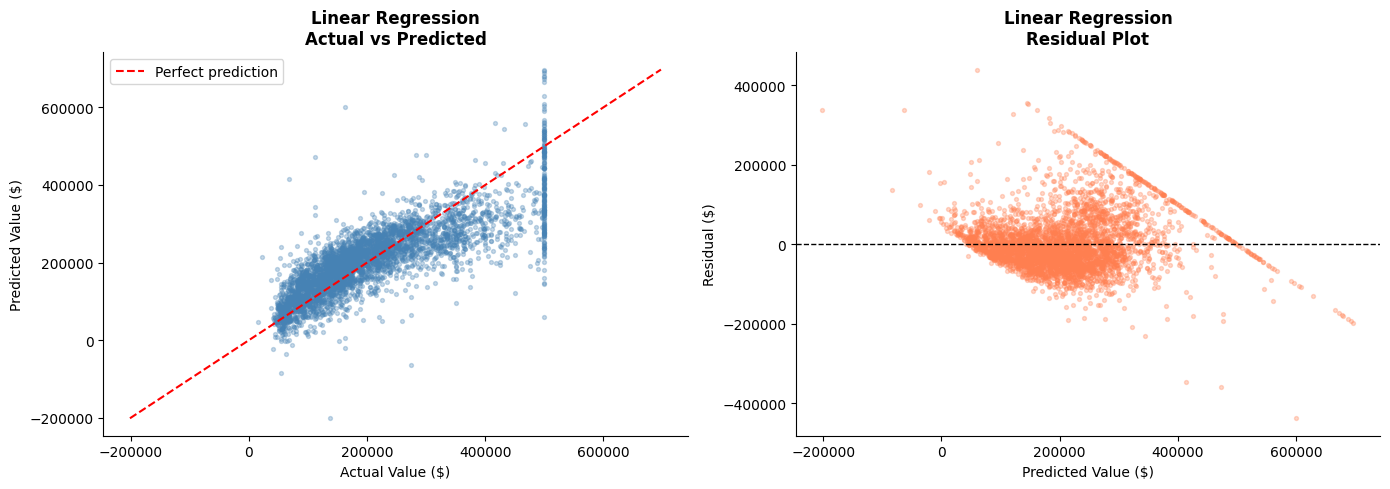

In [15]:
plot_predictions(y_test, y_pred_lr, 'Linear Regression')

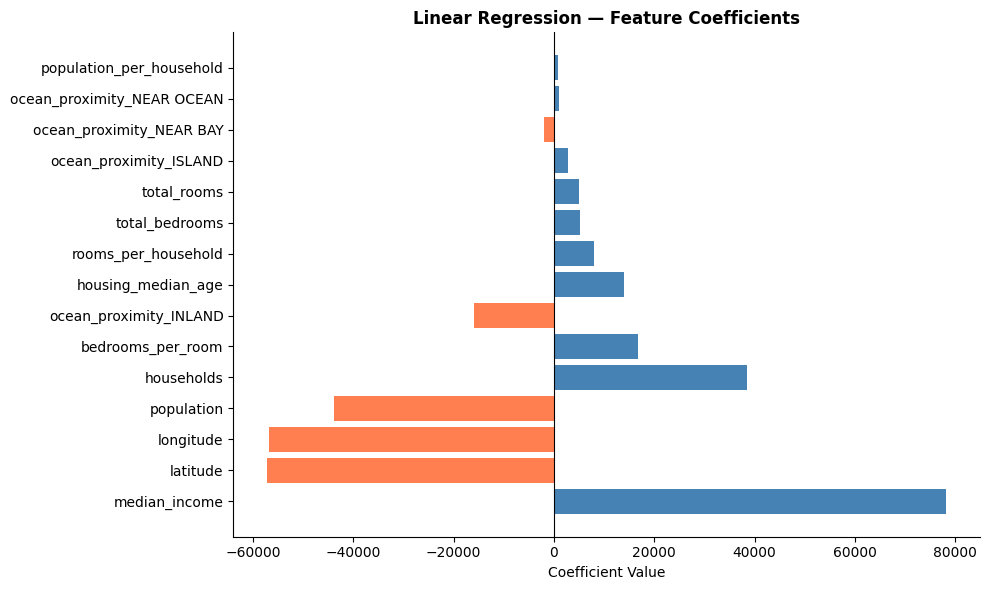


Top 5 most influential features:
      Feature   Coefficient
median_income  78174.853710
     latitude -57159.447231
    longitude -56905.402781
   population -43940.219535
   households  38404.798934


In [16]:
# Feature coefficients
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Linear Regression — Feature Coefficients', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 most influential features:')
print(coef_df.head().to_string(index=False))

---
<a id='5'></a>
## 5. Ridge Regression (L2)

**How it works:** Adds L2 penalty `λ · Σwᵢ²` to the loss — shrinks all coefficients toward zero.  
**Key property:** Never sets weights to exactly zero. Handles multicollinearity.  
**Hyperparameter:** `alpha` (λ) — higher = more shrinkage.

In [ ]:
import numpy as np
alphas = np.logspace(-3, 4, 50)
print(f'Ridge alphas: {alphas.round(3)}')

Ridge alphas: [1.000000e-03 1.000000e-03 2.000000e-03 3.000000e-03 4.000000e-03
 5.000000e-03 7.000000e-03 1.000000e-02 1.400000e-02 1.900000e-02
 2.700000e-02 3.700000e-02 5.200000e-02 7.200000e-02 1.000000e-01
 1.390000e-01 1.930000e-01 2.680000e-01 3.730000e-01 5.180000e-01
 7.200000e-01 1.000000e+00 1.389000e+00 1.931000e+00 2.683000e+00
 3.728000e+00 5.179000e+00 7.197000e+00 1.000000e+01 1.389500e+01
 1.930700e+01 2.682700e+01 3.727600e+01 5.179500e+01 7.196900e+01
 1.000000e+02 1.389500e+02 1.930700e+02 2.682700e+02 3.727590e+02
 5.179470e+02 7.196860e+02 1.000000e+03 1.389495e+03 1.930698e+03
 2.682696e+03 3.727594e+03 5.179475e+03 7.196857e+03 1.000000e+04]


In [ ]:
# Find best alpha via RidgeCV (built-in cross-validation)
alphas = np.logspace(-3, 4, 50)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)

best_alpha_ridge = ridge_cv.alpha_
print(f'Best alpha (λ) for Ridge: {best_alpha_ridge:.4f}')

print('\n=== Ridge Regression ===')
ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = evaluate('Ridge Regression', ridge, X_train_scaled, X_test_scaled, y_train, y_test)

Best alpha (λ) for Ridge: 51.7947

=== Ridge Regression ===
  Train R² : 0.6542
  Test  R² : 0.6514
  RMSE     : $69,041
  MAE      : $49,746


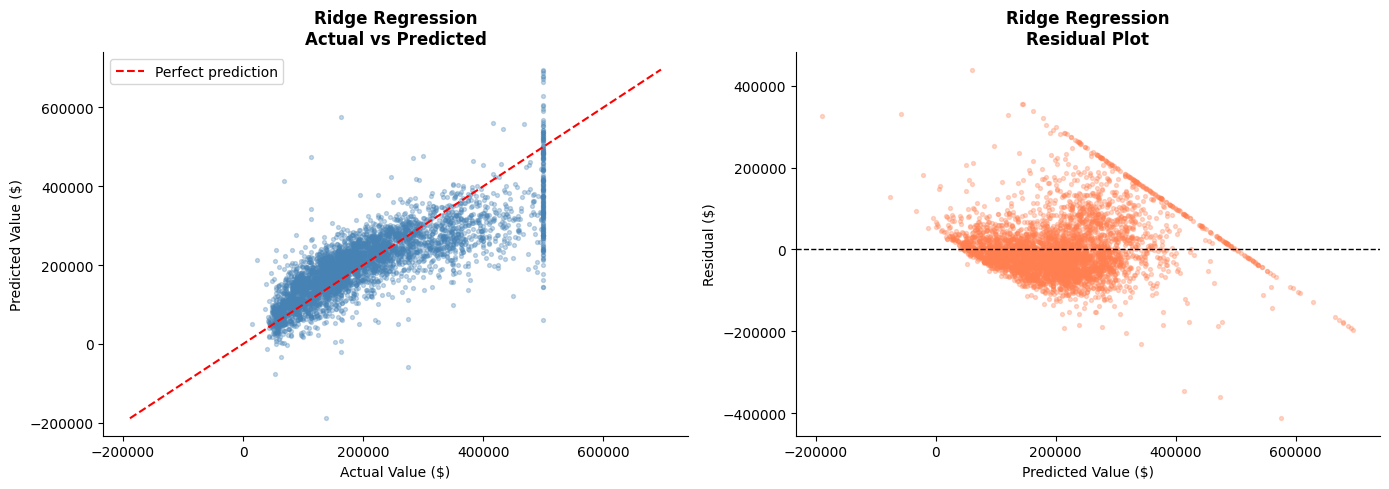

In [18]:
plot_predictions(y_test, y_pred_ridge, 'Ridge Regression')

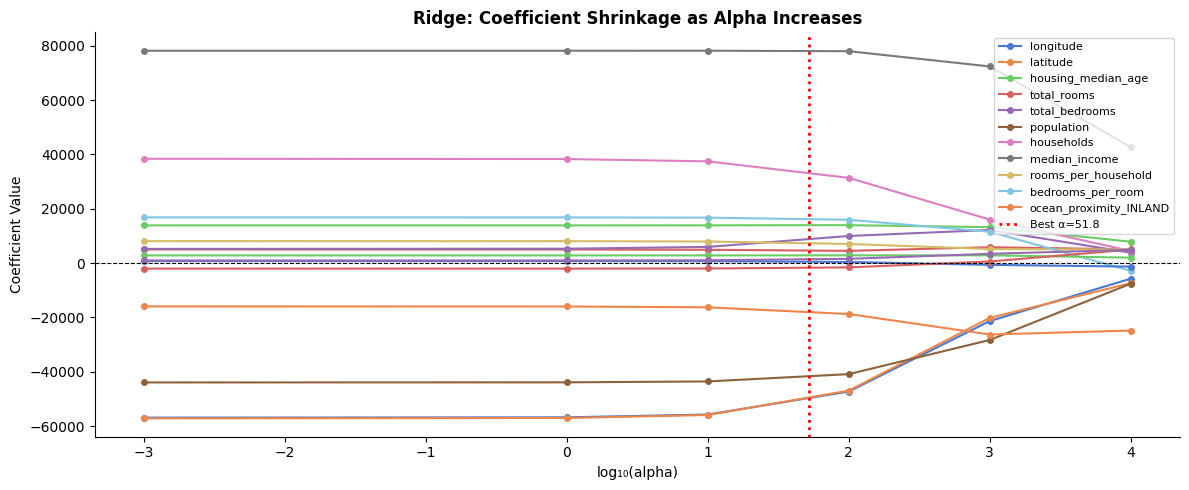

Notice: all coefficients shrink but none reach exactly zero


In [19]:
# Show effect of different alpha values on coefficients
alphas_plot = [0.001, 1, 10, 100, 1000, 10000]
coef_matrix = []

for a in alphas_plot:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    coef_matrix.append(r.coef_)

coef_matrix = np.array(coef_matrix)

plt.figure(figsize=(12, 5))
for i, feat in enumerate(FEATURES):
    plt.plot(np.log10(alphas_plot), coef_matrix[:, i], marker='o', markersize=4, label=feat if abs(coef_matrix[0, i]) > 5000 else None)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(np.log10(best_alpha_ridge), color='red', linestyle=':', linewidth=2, label=f'Best α={best_alpha_ridge:.1f}')
plt.xlabel('log₁₀(alpha)')
plt.ylabel('Coefficient Value')
plt.title('Ridge: Coefficient Shrinkage as Alpha Increases', fontweight='bold')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()
print('Notice: all coefficients shrink but none reach exactly zero')

---
<a id='6'></a>
## 6. Lasso Regression (L1)

**How it works:** Adds L1 penalty `λ · Σ|wᵢ|` to the loss — can shrink weights to **exactly zero**.  
**Key property:** Automatic feature selection — irrelevant features are eliminated.  
**Hyperparameter:** `alpha` (λ) — higher = more features eliminated.

In [20]:
# Find best alpha via LassoCV
lasso_cv = LassoCV(alphas=np.logspace(-3, 4, 50), cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

best_alpha_lasso = lasso_cv.alpha_
print(f'Best alpha (λ) for Lasso: {best_alpha_lasso:.4f}')

print('\n=== Lasso Regression ===')
lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = evaluate('Lasso Regression', lasso, X_train_scaled, X_test_scaled, y_train, y_test)

n_zero = np.sum(lasso.coef_ == 0)
print(f'\nFeatures eliminated (coef=0): {n_zero} / {len(FEATURES)}')
print(f'Features kept               : {len(FEATURES) - n_zero} / {len(FEATURES)}')

Best alpha (λ) for Lasso: 268.2696

=== Lasso Regression ===


  Train R² : 0.6538
  Test  R² : 0.6515
  RMSE     : $69,031
  MAE      : $49,723

Features eliminated (coef=0): 0 / 15
Features kept               : 15 / 15


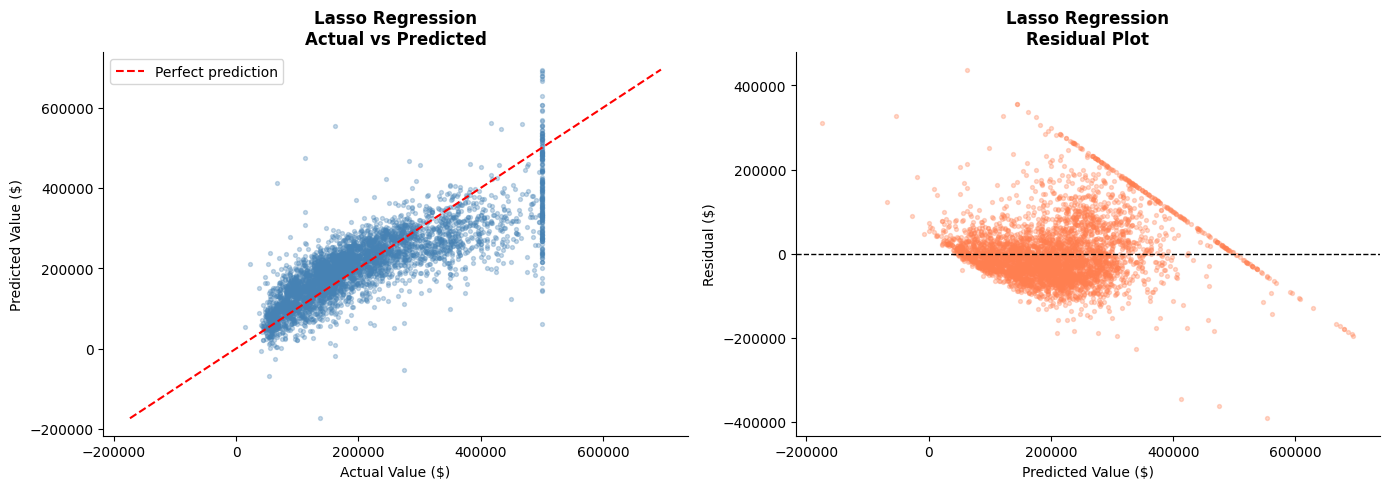

In [21]:
plot_predictions(y_test, y_pred_lasso, 'Lasso Regression')

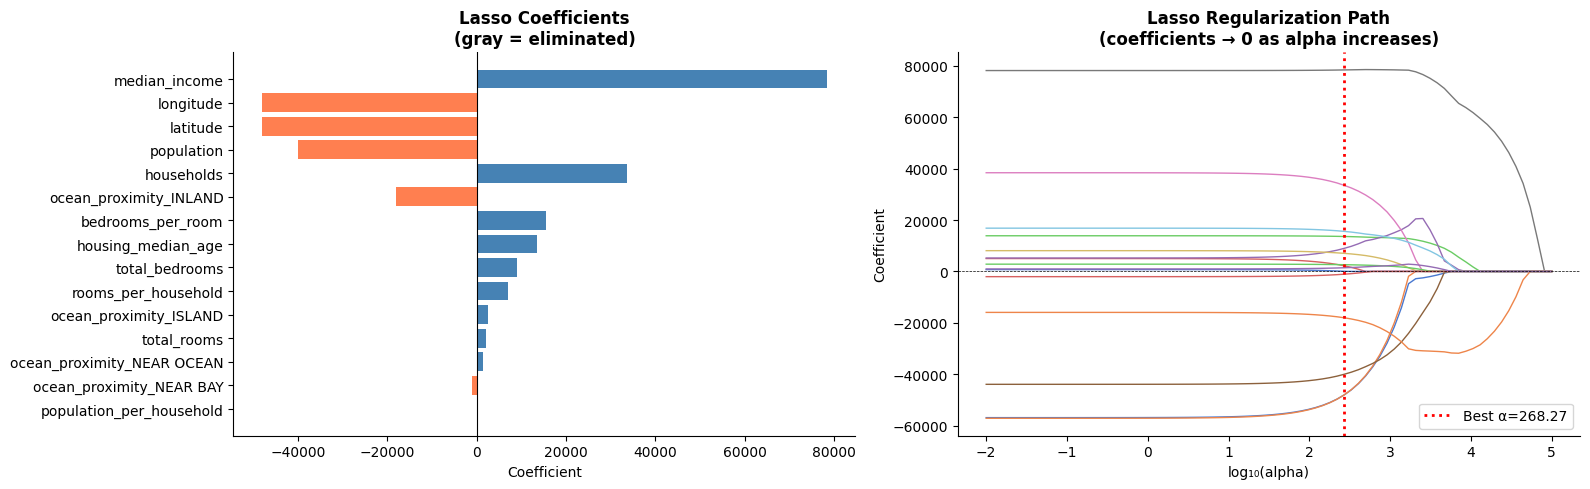

In [22]:
# Show Lasso feature selection
lasso_coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': lasso.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# All coefficients
colors = ['steelblue' if c > 0 else ('coral' if c < 0 else 'lightgray') for c in lasso_coef_df['Coefficient']]
axes[0].barh(lasso_coef_df['Feature'], lasso_coef_df['Coefficient'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Lasso Coefficients\n(gray = eliminated)', fontweight='bold')
axes[0].set_xlabel('Coefficient')

# Coefficient path: effect of alpha on Lasso (sparse vs dense)
alphas_lasso_plot = np.logspace(-2, 5, 80)
coef_path = []
for a in alphas_lasso_plot:
    m = Lasso(alpha=a, max_iter=10000).fit(X_train_scaled, y_train)
    coef_path.append(m.coef_)
coef_path = np.array(coef_path)

for i in range(coef_path.shape[1]):
    axes[1].plot(np.log10(alphas_lasso_plot), coef_path[:, i], linewidth=1)
axes[1].axvline(np.log10(best_alpha_lasso), color='red', linestyle=':', linewidth=2, label=f'Best α={best_alpha_lasso:.2f}')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[1].set_xlabel('log₁₀(alpha)')
axes[1].set_ylabel('Coefficient')
axes[1].set_title('Lasso Regularization Path\n(coefficients → 0 as alpha increases)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
# Ridge vs Lasso coefficient comparison
comp_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Linear Reg' : lr.coef_,
    'Ridge'      : ridge.coef_,
    'Lasso'      : lasso.coef_
}).set_index('Feature').sort_values('Linear Reg', key=abs, ascending=False)

print('Coefficient comparison — Linear vs Ridge vs Lasso:')
print(comp_df.round(0).to_string())

Coefficient comparison — Linear vs Ridge vs Lasso:
                            Linear Reg    Ridge    Lasso
Feature                                                 
median_income                  78175.0  78136.0  78416.0
latitude                      -57159.0 -51339.0 -48106.0
longitude                     -56905.0 -51428.0 -48114.0
population                    -43940.0 -42216.0 -40052.0
households                     38405.0  34171.0  33529.0
bedrooms_per_room              16831.0  16322.0  15595.0
ocean_proximity_INLAND        -15949.0 -17545.0 -18025.0
housing_median_age             13875.0  13934.0  13598.0
rooms_per_household             8074.0   7459.0   7038.0
total_bedrooms                  5216.0   8266.0   8954.0
total_rooms                     5009.0   4614.0   2198.0
ocean_proximity_ISLAND          2821.0   2836.0   2615.0
ocean_proximity_NEAR BAY       -2043.0  -1796.0  -1093.0
ocean_proximity_NEAR OCEAN       963.0   1303.0   1422.0
population_per_household         711.

---
<a id='7'></a>
## 7. Elastic Net (L1 + L2 Combined)

**How it works:** Combines Ridge (L2) and Lasso (L1) penalties.  
**Formula:** `Loss = MSE + λ₁·Σ|wᵢ| + λ₂·Σwᵢ²`  
**Key property:** Does feature selection (like Lasso) + stable with correlated features (like Ridge).  
**Hyperparameters:** `alpha` (total strength) and `l1_ratio` (0=Ridge, 1=Lasso).

In [24]:
from sklearn.linear_model import ElasticNetCV

enet_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
    alphas=np.logspace(-3, 3, 30),
    cv=5, max_iter=10000, random_state=42
)
enet_cv.fit(X_train_scaled, y_train)

print(f'Best alpha    : {enet_cv.alpha_:.4f}')
print(f'Best l1_ratio : {enet_cv.l1_ratio_:.2f}  (0=Ridge, 1=Lasso)')

print('\n=== Elastic Net ===')
enet = ElasticNet(alpha=enet_cv.alpha_, l1_ratio=enet_cv.l1_ratio_, max_iter=10000)
enet.fit(X_train_scaled, y_train)
y_pred_enet = evaluate('Elastic Net', enet, X_train_scaled, X_test_scaled, y_train, y_test)

n_zero_enet = np.sum(enet.coef_ == 0)
print(f'\nFeatures eliminated: {n_zero_enet} / {len(FEATURES)}')

Best alpha    : 239.5027
Best l1_ratio : 1.00  (0=Ridge, 1=Lasso)

=== Elastic Net ===


  Train R² : 0.6540
  Test  R² : 0.6516
  RMSE     : $69,027
  MAE      : $49,724

Features eliminated: 0 / 15


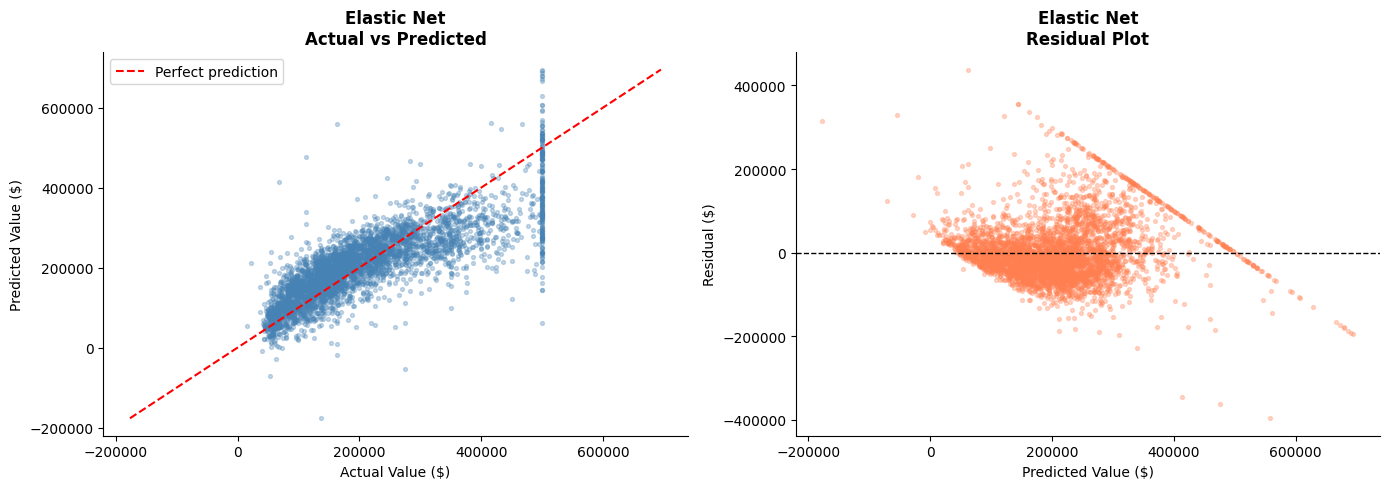

In [25]:
plot_predictions(y_test, y_pred_enet, 'Elastic Net')

---
<a id='8'></a>
## 8. Polynomial Regression

**How it works:** Creates polynomial + interaction features from originals, then applies Linear/Ridge regression.  
**Formula:** `ŷ = w₀ + w₁x + w₂x² + w₃x₁x₂ + ...`  
**Key property:** Captures non-linear relationships.  
**Warning:** Feature count explodes — always pair with regularization.

In [26]:
# Show feature explosion
for deg in [1, 2, 3]:
    pf = PolynomialFeatures(degree=deg, include_bias=False)
    n = pf.fit_transform(X_train_scaled).shape[1]
    print(f'Degree {deg}: {X_train_scaled.shape[1]} features → {n} features')

Degree 1: 15 features → 15 features
Degree 2: 15 features → 135 features
Degree 3: 15 features → 815 features


In [ ]:
# Degree 2 + Ridge (regularization essential at degree 2+)
poly_pipeline = Pipeline([
    ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=100))
])

# Cross-validate to pick best alpha for poly+ridge
from sklearn.model_selection import GridSearchCV

param_grid = {'ridge__alpha': [0.1, 1, 10, 100, 1000, 10000]}
gs = GridSearchCV(poly_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
gs.fit(X_train_scaled, y_train) 

best_poly_alpha = gs.best_params_['ridge__alpha']
print(f'Best Ridge alpha for Polynomial model: {best_poly_alpha}')

poly_ridge = Pipeline([
    ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=best_poly_alpha))
])
poly_ridge.fit(X_train_scaled, y_train)

print('\n=== Polynomial Regression (degree=2) + Ridge ===')
y_pred_poly = evaluate('Polynomial (deg=2) + Ridge', poly_ridge, X_train_scaled, X_test_scaled, y_train, y_test)

Best Ridge alpha for Polynomial model: 1000

=== Polynomial Regression (degree=2) + Ridge ===
  Train R² : 0.6928
  Test  R² : 0.6865
  RMSE     : $65,478
  MAE      : $47,135


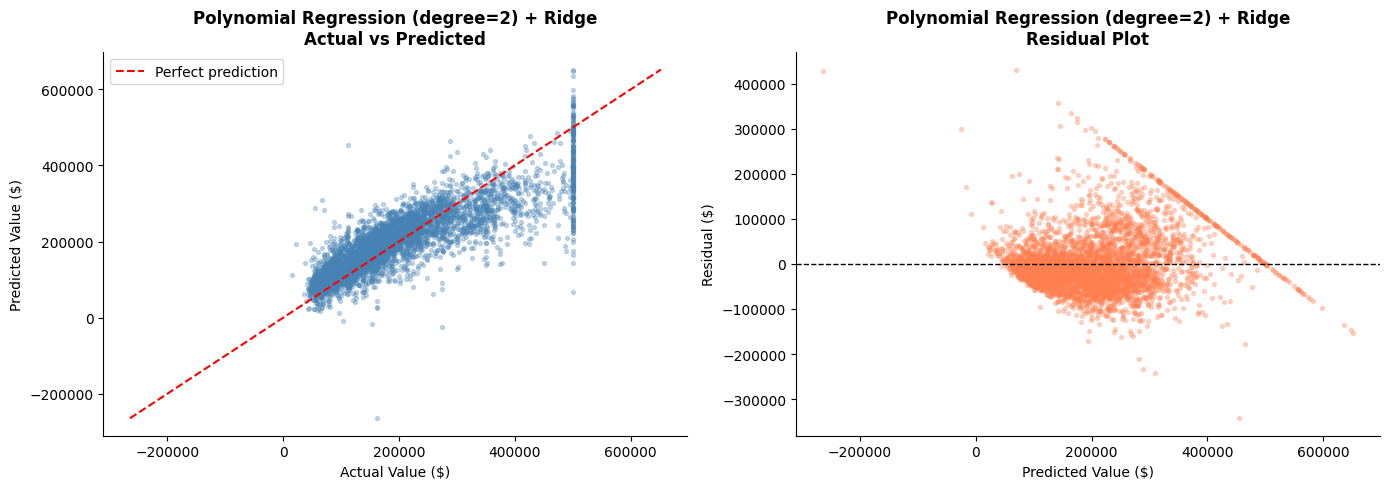

In [28]:
plot_predictions(y_test, y_pred_poly, 'Polynomial Regression (degree=2) + Ridge')

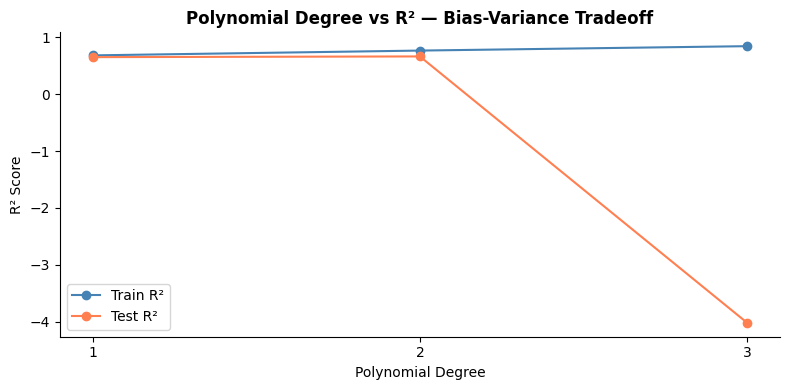

Gap between train/test R² grows = overfitting increases with degree


In [29]:
# Show overfitting risk: training vs test R² across degrees (on a subset for speed)
sample_idx = np.random.RandomState(42).choice(len(X_train_scaled), 3000, replace=False)
X_tr_s = X_train_scaled[sample_idx]
y_tr_s = y_train.values[sample_idx]

degrees = [1, 2, 3]
train_r2s, test_r2s = [], []

for deg in degrees:
    p = Pipeline([
        ('poly',  PolynomialFeatures(degree=deg, include_bias=False)),
        ('ridge', Ridge(alpha=1.0))
    ])
    p.fit(X_tr_s, y_tr_s)
    train_r2s.append(r2_score(y_tr_s, p.predict(X_tr_s)))
    test_r2s.append(r2_score(y_test, p.predict(X_test_scaled)))

plt.figure(figsize=(8, 4))
plt.plot(degrees, train_r2s, 'o-', label='Train R²', color='steelblue')
plt.plot(degrees, test_r2s,  'o-', label='Test R²',  color='coral')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Polynomial Degree vs R² — Bias-Variance Tradeoff', fontweight='bold')
plt.legend()
plt.xticks(degrees)
plt.tight_layout()
plt.show()
print('Gap between train/test R² grows = overfitting increases with degree')

---
<a id='9'></a>
## 9. Model Comparison

In [30]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Test R²', ascending=False)
print('=== Final Model Comparison ===')
print(results_df.to_string())

=== Final Model Comparison ===
                            Train R²  Test R²  RMSE ($)  MAE ($)
Polynomial (deg=2) + Ridge    0.6928   0.6865   65478.0  47135.0
Elastic Net                   0.6540   0.6516   69027.0  49724.0
Lasso Regression              0.6538   0.6515   69031.0  49723.0
Linear Regression             0.6544   0.6514   69043.0  49775.0
Ridge Regression              0.6542   0.6514   69041.0  49746.0


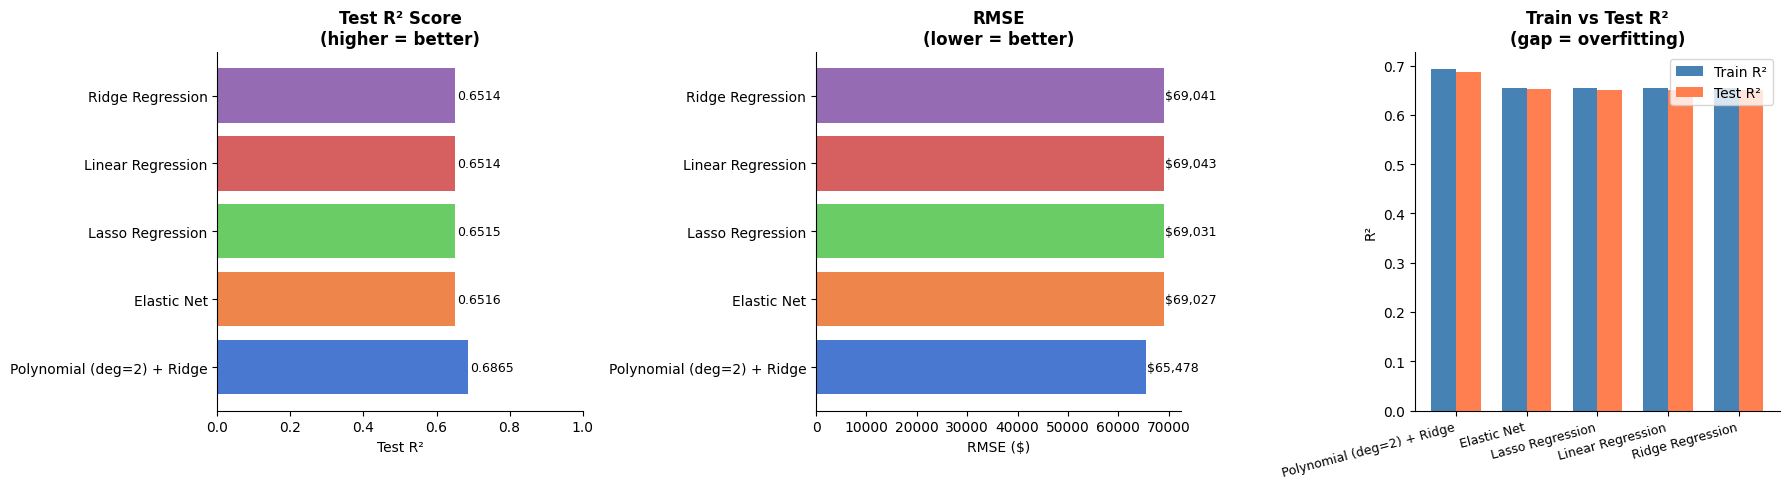

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = results_df.index.tolist()
palette = sns.color_palette('muted', len(models))

# Test R²
bars = axes[0].barh(models, results_df['Test R²'], color=palette)
axes[0].set_xlabel('Test R²')
axes[0].set_title('Test R² Score\n(higher = better)', fontweight='bold')
axes[0].set_xlim(0, 1)
for bar, val in zip(bars, results_df['Test R²']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

# RMSE
bars2 = axes[1].barh(models, results_df['RMSE ($)'], color=palette)
axes[1].set_xlabel('RMSE ($)')
axes[1].set_title('RMSE\n(lower = better)', fontweight='bold')
for bar, val in zip(bars2, results_df['RMSE ($)']):
    axes[1].text(val + 200, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=9)

# Train vs Test R² (overfitting check)
x = np.arange(len(models))
w = 0.35
axes[2].bar(x - w/2, results_df['Train R²'], w, label='Train R²', color='steelblue')
axes[2].bar(x + w/2, results_df['Test R²'],  w, label='Test R²',  color='coral')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=15, ha='right', fontsize=9)
axes[2].set_ylabel('R²')
axes[2].set_title('Train vs Test R²\n(gap = overfitting)', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

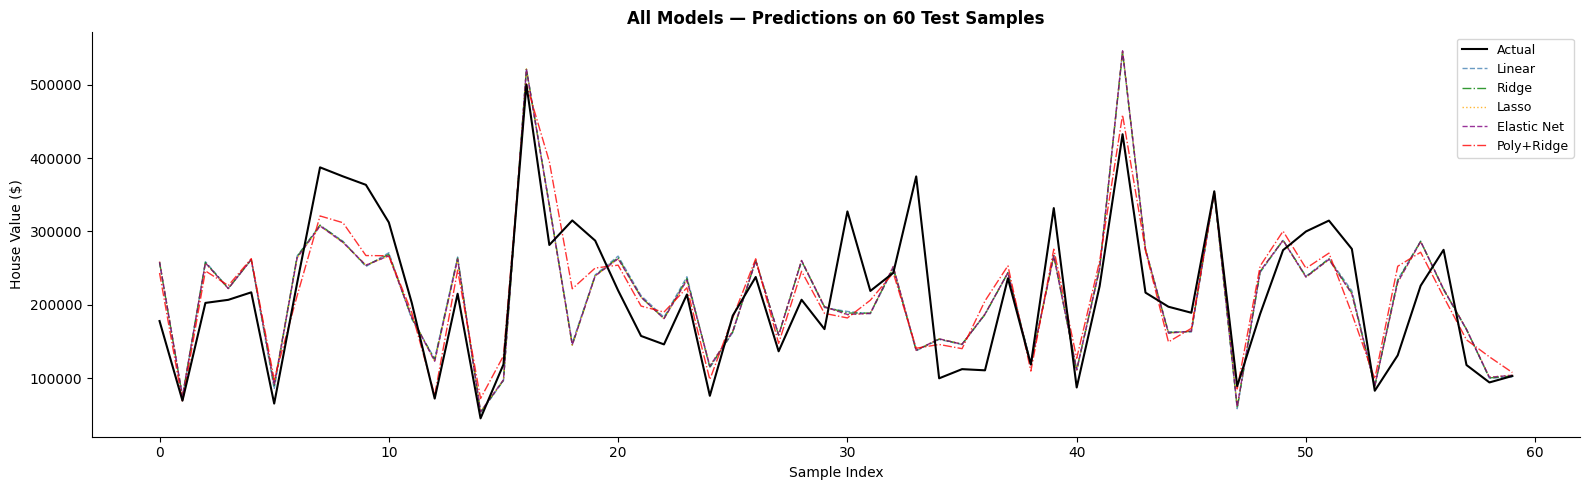

In [32]:
# Prediction comparison — all models on same test samples
sample_n = 60
idx = np.random.RandomState(0).choice(len(y_test), sample_n, replace=False)
y_sample = y_test.values[idx]

preds = {
    'Actual'           : y_sample,
    'Linear'           : y_pred_lr[idx],
    'Ridge'            : y_pred_ridge[idx],
    'Lasso'            : y_pred_lasso[idx],
    'Elastic Net'      : y_pred_enet[idx],
    'Poly+Ridge'       : y_pred_poly[idx],
}

plt.figure(figsize=(16, 5))
x_ax = np.arange(sample_n)
plt.plot(x_ax, preds['Actual'], 'k-', linewidth=1.5, label='Actual', zorder=5)

styles = ['--', '-.', ':', '--', '-.']
colors = ['steelblue', 'green', 'orange', 'purple', 'red']
for (name, pred), style, color in zip(list(preds.items())[1:], styles, colors):
    plt.plot(x_ax, pred, style, linewidth=1, label=name, color=color, alpha=0.8)

plt.xlabel('Sample Index')
plt.ylabel('House Value ($)')
plt.title(f'All Models — Predictions on {sample_n} Test Samples', fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

In [33]:
print('='*60)
print('          FINAL SUMMARY')
print('='*60)
print(f'{"Model":<30} {"Test R²":>8} {"RMSE ($)":>12} {"MAE ($)":>10}')
print('-'*60)
for model, row in results_df.iterrows():
    overfit = '⚠ overfit' if (row['Train R²'] - row['Test R²']) > 0.05 else ''
    print(f'{model:<30} {row["Test R²"]:>8.4f} {row["RMSE ($)"]:>12,.0f} {row["MAE ($)"]:>10,.0f}  {overfit}')
print('='*60)
best = results_df['Test R²'].idxmax()
print(f'\nBest model: {best} (Test R² = {results_df.loc[best, "Test R²"]:.4f})')
print('\nKey takeaways:')
print('  - Ridge/Lasso/ElasticNet reduce overfitting vs plain Linear Regression')
print('  - Lasso performs feature selection (eliminates irrelevant weights)')
print('  - Polynomial captures non-linear patterns but needs regularization')
print('  - ElasticNet balances the strengths of both Ridge and Lasso')

          FINAL SUMMARY
Model                           Test R²     RMSE ($)    MAE ($)
------------------------------------------------------------
Polynomial (deg=2) + Ridge       0.6865       65,478     47,135  
Elastic Net                      0.6516       69,027     49,724  
Lasso Regression                 0.6515       69,031     49,723  
Linear Regression                0.6514       69,043     49,775  
Ridge Regression                 0.6514       69,041     49,746  

Best model: Polynomial (deg=2) + Ridge (Test R² = 0.6865)

Key takeaways:
  - Ridge/Lasso/ElasticNet reduce overfitting vs plain Linear Regression
  - Lasso performs feature selection (eliminates irrelevant weights)
  - Polynomial captures non-linear patterns but needs regularization
  - ElasticNet balances the strengths of both Ridge and Lasso
